# 07 — Final Model Investigation

## Objective

Previous experiments showed that strict group-held-out evaluation leads
to a substantial loss of performance. Several mitigation strategies,
including MRI-safe augmentation, group weighting, and group-aware
sampling, produced only limited improvements.

This notebook takes a different approach.

The objective is to determine whether a strong and defensible
classification model can still be obtained from this dataset under a
final evaluation protocol designed to prevent data leakage without
requiring strict generalization to entirely unseen split groups.

The investigation follows a bounded experimental strategy:

1. Define the final train/validation/test split.
2. Train a clean EfficientNetV2B0 reference model.
3. Assess whether performance is sufficiently promising to justify
   further optimization.
4. If necessary, evaluate one alternative pretrained backbone.
5. Perform at most two targeted optimization experiments if the
   reference performance indicates that meaningful improvement is
   achievable.
6. Select the final model using validation performance only.
7. Evaluate the selected model once on the held-out test set.

The strict group-held-out experiments from Notebook 06 are retained as
a separate generalization stress test and are not discarded.

In [20]:
# ============================================================
# Step 0.1 — Restore raw dataset
# ============================================================

from google.colab import userdata
from pathlib import Path
import os

PROJECT_ROOT = Path("/content/brain-tumor-mri")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/brain-tumor-mri/models"
)

DRIVE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("✓ Kaggle authentication ready.")

image_files = list(RAW_DIR.rglob("*.jpg"))

if len(image_files) != 11300:
    !kaggle datasets download \
        -d fernando2rad/brain-tumor-mri-images-30-classes \
        -p /content/brain-tumor-mri/data/raw \
        --unzip

image_files = list(RAW_DIR.rglob("*.jpg"))

print("Images found:", len(image_files))
print("DATA.json exists:", (RAW_DIR / "DATA.json").exists())

assert len(image_files) == 11300, (
    f"Expected 11300 images, found {len(image_files)}."
)

✓ Kaggle authentication ready.
Images found: 11300
DATA.json exists: True


In [21]:
HEAD_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_duplicate_safe_head.keras"
)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# ============================================================
# Step 0.2 — Restore frozen classification manifest
# ============================================================

import pandas as pd
import shutil

MANIFEST_PATH = (
    PROCESSED_DIR
    / "classification_manifest.csv"
)

DRIVE_MANIFEST = Path(
    "/content/drive/MyDrive/classification_manifest.csv"
)

print(
    "Frozen manifest on Drive:",
    DRIVE_MANIFEST.exists()
)

assert DRIVE_MANIFEST.exists(), (
    "Frozen classification manifest not found on Google Drive."
)

shutil.copy2(
    DRIVE_MANIFEST,
    MANIFEST_PATH
)

manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Manifest shape:", manifest.shape)

print("\nSplit counts:")
print(
    manifest["split"].value_counts()
)

print("\nColumns:")
print(
    manifest.columns.tolist()
)

print("\nUnique split groups:")
print(
    manifest["split_group"].nunique()
)

print("\nPathologies:")
print(
    manifest["pathology"].value_counts()
)

Frozen manifest on Drive: True
Manifest shape: (11300, 12)

Split counts:
split
train         7928
validation    1699
test          1673
Name: count, dtype: int64

Columns:
['relative_path', 'resolved_relative_path', 'pathology', 'modality', 'split_group', 'split', 'width', 'height', 'point', 'location', 'description', 'pixel_hash']

Unique split groups:
357

Pathologies:
pathology
Meningioma            2071
Other                 1533
Glioma                1476
Schwannoma            1236
Astrocytoma           1118
Normal                1058
Ependymoma            1037
Neurocytoma            618
Hemangiopericytoma     603
Oligodendroglioma      550
Name: count, dtype: int64


In [7]:
# ============================================================
# Step 0.3 — Resolve Windows-style manifest paths
# ============================================================

from pathlib import Path, PureWindowsPath

# Images already indexed
image_files = list(RAW_DIR.rglob("*.jpg"))

path_lookup = {
    p.name: str(p)
    for p in image_files
}

# Extract filename correctly from Windows-style paths
manifest["filename"] = (
    manifest["relative_path"]
    .apply(lambda x: PureWindowsPath(str(x)).name)
)

manifest["current_path"] = (
    manifest["filename"]
    .map(path_lookup)
)

print("Images indexed :", len(image_files))
print("Images resolved:", manifest["current_path"].notna().sum())
print("Images missing :", manifest["current_path"].isna().sum())

display(
    manifest[
        [
            "relative_path",
            "filename",
            "current_path",
            "pathology",
            "split_group",
            "split"
        ]
    ].head()
)

Images indexed : 11300
Images resolved: 11278
Images missing : 22


,relative_path,filename,current_path,pathology,split_group,split
0,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,"T1C+ - Diffuse astrocytoma frontal , ventricle...",/content/brain-tumor-mri/data/raw/Astrocytoma ...,Astrocytoma,9,test
1,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,"T1C+ - Diffuse astrocytoma frontal , ventricle...",/content/brain-tumor-mri/data/raw/Astrocytoma ...,Astrocytoma,9,test
2,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,"T1C+ - Diffuse astrocytoma frontal , ventricle...",/content/brain-tumor-mri/data/raw/Astrocytoma ...,Astrocytoma,9,test
3,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,"T1C+ - Diffuse astrocytoma frontal , ventricle...",/content/brain-tumor-mri/data/raw/Astrocytoma ...,Astrocytoma,9,test
4,Astrocytoma T1\T1 - Diffuse astrocytoma fronta...,"T1 - Diffuse astrocytoma frontal , ventricle 0...",/content/brain-tumor-mri/data/raw/Astrocytoma ...,Astrocytoma,9,test


In [8]:
# ============================================================
# Step 0.4 — Diagnose the 22 unresolved paths
# ============================================================

missing = manifest[
    manifest["current_path"].isna()
].copy()

print("Missing images:", len(missing))

print("\nManifest paths:")
for p in missing["relative_path"]:
    print(repr(p))

print("\n--- Example actual dataset paths ---")
for p in image_files[:10]:
    print(p.relative_to(RAW_DIR))

Missing images: 22

Manifest paths:
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 001.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 002.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 003.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 004.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 005.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 006.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 007.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 008.jpg'
'Glioma T1C+\\T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 009.jpg'
'Glioma T2\\T2 - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 001.jpg'
'Glioma T2\\T2 - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 00

In [11]:
# ============================================================
# Step 0.5 — Final robust path resolution
# ============================================================

import unicodedata

def normalize_path_string(s):
    s = str(s).replace("\\", "/")
    s = unicodedata.normalize("NFKC", s)

    # Normalize dash variants + observed encoding artifact
    s = s.replace("â€“", "-")

    for dash in ["–", "—", "−"]:
        s = s.replace(dash, "-")

    return s


# Build lookup from actual dataset paths
normalized_lookup = {
    normalize_path_string(p.relative_to(RAW_DIR)): str(p)
    for p in image_files
}

# Resolve manifest paths
manifest["current_path"] = (
    manifest["relative_path"]
    .apply(normalize_path_string)
    .map(normalized_lookup)
)

print("Images resolved:", manifest["current_path"].notna().sum())
print("Images missing :", manifest["current_path"].isna().sum())

assert manifest["current_path"].notna().all()

print("\n✓ All 11,300 images successfully resolved.")

Images resolved: 11300
Images missing : 0

✓ All 11,300 images successfully resolved.


In [12]:
# ============================================================
# Step 1 — Image-level stratified experimental split
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42

# Work from row indices so the original manifest stays intact
all_idx = manifest.index.to_numpy()
all_labels = manifest["pathology"].to_numpy()

# 70% train / 30% temporary
train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels
)

# Split remaining 30% equally:
# 15% validation / 15% test
temp_labels = manifest.loc[temp_idx, "pathology"]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

manifest["experimental_split"] = None

manifest.loc[train_idx, "experimental_split"] = "train"
manifest.loc[val_idx, "experimental_split"] = "validation"
manifest.loc[test_idx, "experimental_split"] = "test"

print("Experimental split counts:")
print(manifest["experimental_split"].value_counts())

print("\nPathology distribution (%):")
display(
    pd.crosstab(
        manifest["pathology"],
        manifest["experimental_split"],
        normalize="columns"
    ).mul(100).round(2)
)

Experimental split counts:
experimental_split
train         7910
test          1695
validation    1695
Name: count, dtype: int64

Pathology distribution (%):


experimental_split,test,train,validation
pathology,,,
Astrocytoma,9.85,9.90,9.91
Ependymoma,9.14,9.18,9.20
Glioma,13.10,13.06,13.04
Hemangiopericytoma,5.37,5.34,5.31
Meningioma,18.35,18.33,18.29
Neurocytoma,5.49,5.46,5.49
Normal,9.32,9.37,9.38
Oligodendroglioma,4.90,4.87,4.84
Other,13.57,13.57,13.57


In [13]:
# ============================================================
# Step 1.1 — Audit group overlap in experimental split
# ============================================================

group_overlap = (
    manifest
    .groupby("split_group")["experimental_split"]
    .agg(
        n_splits="nunique",
        splits=lambda x: sorted(x.unique())
    )
    .reset_index()
)

print("Total split groups:", len(group_overlap))

print("\nNumber of partitions represented per group:")
print(
    group_overlap["n_splits"]
    .value_counts()
    .sort_index()
)

print("\nGroups appearing in >1 partition:",
      (group_overlap["n_splits"] > 1).sum())

print(
    "Percentage:",
    round(
        100 * (group_overlap["n_splits"] > 1).mean(),
        2
    ),
    "%"
)

print("\nGroups appearing in train + validation + test:",
      (group_overlap["n_splits"] == 3).sum())

Total split groups: 357

Number of partitions represented per group:
n_splits
1     13
2     56
3    288
Name: count, dtype: int64

Groups appearing in >1 partition: 344
Percentage: 96.36 %

Groups appearing in train + validation + test: 288


In [14]:
# ============================================================
# Step 1.2 — Exact duplicate leakage audit
# ============================================================

hash_overlap = (
    manifest
    .groupby("pixel_hash")["experimental_split"]
    .nunique()
)

cross_split_hashes = hash_overlap[hash_overlap > 1]

print("Unique pixel hashes:", manifest["pixel_hash"].nunique())

print(
    "Exact duplicate hashes crossing partitions:",
    len(cross_split_hashes)
)

affected_images = manifest[
    manifest["pixel_hash"].isin(cross_split_hashes.index)
]

print(
    "Images involved:",
    len(affected_images)
)

Unique pixel hashes: 9435
Exact duplicate hashes crossing partitions: 744
Images involved: 1783


In [15]:
# ============================================================
# Step 2 — Duplicate-safe image-level experimental split
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42

# One row per unique image content
hash_units = (
    manifest
    .groupby("pixel_hash", as_index=False)
    .agg(
        pathology=("pathology", "first"),
        n_images=("pixel_hash", "size")
    )
)

print("Unique pixel-hash units:", len(hash_units))
print("Total images represented:", hash_units["n_images"].sum())

# ------------------------------------------------------------
# 70% train / 30% temporary, stratified by pathology
# ------------------------------------------------------------

train_hashes, temp_hashes = train_test_split(
    hash_units,
    test_size=0.30,
    random_state=SEED,
    stratify=hash_units["pathology"]
)

# ------------------------------------------------------------
# Remaining 30% -> 15% validation / 15% test
# ------------------------------------------------------------

val_hashes, test_hashes = train_test_split(
    temp_hashes,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_hashes["pathology"]
)

# Map pixel_hash -> experimental partition
hash_to_split = {}

hash_to_split.update({
    h: "train"
    for h in train_hashes["pixel_hash"]
})

hash_to_split.update({
    h: "validation"
    for h in val_hashes["pixel_hash"]
})

hash_to_split.update({
    h: "test"
    for h in test_hashes["pixel_hash"]
})

manifest["duplicate_safe_split"] = (
    manifest["pixel_hash"].map(hash_to_split)
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("\nImage counts:")
print(manifest["duplicate_safe_split"].value_counts())

print("\nImage percentages:")
print(
    manifest["duplicate_safe_split"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPathology distribution (%):")
display(
    pd.crosstab(
        manifest["pathology"],
        manifest["duplicate_safe_split"],
        normalize="columns"
    ).mul(100).round(2)
)

assert manifest["duplicate_safe_split"].notna().all()

# No exact pixel hash may cross partitions
assert (
    manifest
    .groupby("pixel_hash")["duplicate_safe_split"]
    .nunique()
    .max()
    == 1
)

print("\n✓ No exact duplicate crosses partitions.")

Unique pixel-hash units: 9435
Total images represented: 11300

Image counts:
duplicate_safe_split
train         7965
test          1676
validation    1659
Name: count, dtype: int64

Image percentages:
duplicate_safe_split
train         70.49
test          14.83
validation    14.68
Name: proportion, dtype: float64

Pathology distribution (%):


duplicate_safe_split,test,train,validation
pathology,,,
Astrocytoma,9.90,9.81,10.31
Ependymoma,8.83,9.28,9.04
Glioma,12.83,13.09,13.14
Hemangiopericytoma,5.25,5.34,5.42
Meningioma,18.38,18.37,18.08
Neurocytoma,5.61,5.49,5.24
Normal,9.55,9.28,9.58
Oligodendroglioma,5.31,4.80,4.76
Other,14.02,13.51,13.38



✓ No exact duplicate crosses partitions.


In [16]:
# ============================================================
# Step 2.1 — Final audit of duplicate-safe split
# ============================================================

group_overlap_b = (
    manifest
    .groupby("split_group")["duplicate_safe_split"]
    .agg(
        n_splits="nunique",
        splits=lambda x: sorted(x.unique())
    )
    .reset_index()
)

print("Total split groups:", len(group_overlap_b))

print("\nNumber of partitions represented per group:")
print(
    group_overlap_b["n_splits"]
    .value_counts()
    .sort_index()
)

n_crossing = (group_overlap_b["n_splits"] > 1).sum()
n_all_three = (group_overlap_b["n_splits"] == 3).sum()

print("\nGroups appearing in >1 partition:", n_crossing)
print(
    "Percentage:",
    round(100 * n_crossing / len(group_overlap_b), 2),
    "%"
)

print(
    "\nGroups appearing in train + validation + test:",
    n_all_three
)

# Exact duplicate verification
max_hash_splits = (
    manifest
    .groupby("pixel_hash")["duplicate_safe_split"]
    .nunique()
    .max()
)

print("\nMaximum partitions per pixel hash:", max_hash_splits)

assert max_hash_splits == 1

print("\n✓ Final diagnostic split validated.")

Total split groups: 357

Number of partitions represented per group:
n_splits
1     23
2     75
3    259
Name: count, dtype: int64

Groups appearing in >1 partition: 334
Percentage: 93.56 %

Groups appearing in train + validation + test: 259

Maximum partitions per pixel hash: 1

✓ Final diagnostic split validated.


In [17]:
# ============================================================
# Step 3 — TensorFlow datasets for duplicate-safe experiment
# ============================================================

import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Fixed class order
CLASS_NAMES = sorted(manifest["pathology"].unique())
NUM_CLASSES = len(CLASS_NAMES)

class_to_idx = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)


# ------------------------------------------------------------
# Split dataframes
# ------------------------------------------------------------

train_df = manifest[
    manifest["duplicate_safe_split"] == "train"
].copy()

val_df = manifest[
    manifest["duplicate_safe_split"] == "validation"
].copy()

test_df = manifest[
    manifest["duplicate_safe_split"] == "test"
].copy()

for df in [train_df, val_df, test_df]:
    df["label"] = df["pathology"].map(class_to_idx).astype("int32")

print("\nDataset sizes:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))


# ------------------------------------------------------------
# Image loader
# ------------------------------------------------------------

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    return image, label


def make_dataset(df, training=False):
    paths = df["current_path"].astype(str).values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)


# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

images, labels = next(iter(train_ds))

print("\nBatch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Pixel range:",
      float(tf.reduce_min(images)),
      "→",
      float(tf.reduce_max(images)))

print("\n✓ TensorFlow datasets ready.")

Classes: ['Astrocytoma', 'Ependymoma', 'Glioma', 'Hemangiopericytoma', 'Meningioma', 'Neurocytoma', 'Normal', 'Oligodendroglioma', 'Other', 'Schwannoma']
Number of classes: 10

Dataset sizes:
Train      : 7965
Validation : 1659
Test       : 1676

Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32,)
Pixel range: 0.0 → 255.0

✓ TensorFlow datasets ready.


In [18]:
# ============================================================
# Step 4 — Fresh EfficientNetV2B0 baseline
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(SEED)

# ------------------------------------------------------------
# Data augmentation
# ------------------------------------------------------------

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)


# ------------------------------------------------------------
# Fresh ImageNet backbone
# ------------------------------------------------------------

backbone = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True
)

# Stage 1: freeze entire backbone
backbone.trainable = False


# ------------------------------------------------------------
# Classification model
# ------------------------------------------------------------

inputs = keras.Input(shape=(*IMG_SIZE, 3))

x = data_augmentation(inputs)

x = backbone(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="efficientnetv2b0_duplicate_safe"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters     :", model.count_params())
print(
    "Trainable parameters :",
    sum(np.prod(v.shape) for v in model.trainable_weights)
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters     : 5932122
Trainable parameters : 12810


Model: "efficientnetv2b0_duplicate_safe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [22]:
# ============================================================
# Step 4.1 — Train classification head
# ============================================================

HEAD_MODEL_PATH = (
    DRIVE_MODEL_DIR /
    "efficientnetv2b0_duplicate_safe_head.keras"
)

callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        HEAD_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_head
)

Epoch 1/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2593 - loss: 2.0503
Epoch 1: val_loss improved from None to 1.63135, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_head.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_head.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.3330 - loss: 1.8744 - val_accuracy: 0.4262 - val_loss: 1.6314 - learning_rate: 0.0010
Epoch 2/12
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4505 - loss: 1.6009
Epoch 2: val_loss improved from 1.63135 to 1.50362, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_head.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_head.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 26s 99ms/step - accuracy: 0.4598 - loss: 1.5723 - val_accuracy: 0.4756 - val_loss: 1.5036 - le

In [23]:
# ============================================================
# Step 5 — Partial fine-tuning
# ============================================================

# Backbone becomes globally trainable first
backbone.trainable = True

# Freeze everything
for layer in backbone.layers:
    layer.trainable = False

# Unfreeze only block6h + top_conv
for layer in backbone.layers:
    if layer.name.startswith("block6h") or layer.name == "top_conv":
        layer.trainable = True

# Keep BatchNorm frozen
for layer in backbone.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False


print(
    "Trainable backbone layers:",
    sum(layer.trainable for layer in backbone.layers)
)

print(
    "Trainable parameters:",
    sum(np.prod(v.shape) for v in model.trainable_weights)
)


# IMPORTANT: recompile after changing trainable status
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Trainable backbone layers: 13
Trainable parameters: 823098


In [24]:
# ============================================================
# Step 5.1 — Fine-tune
# ============================================================

FINETUNED_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_duplicate_safe_finetuned.keras"
)

callbacks_ft = [
    keras.callbacks.ModelCheckpoint(
        FINETUNED_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_ft
)

Epoch 1/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6040 - loss: 1.1731
Epoch 1: val_loss improved from None to 1.15409, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_finetuned.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.6137 - loss: 1.1471 - val_accuracy: 0.6172 - val_loss: 1.1541 - learning_rate: 1.0000e-05
Epoch 2/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6251 - loss: 1.1352
Epoch 2: val_loss improved from 1.15409 to 1.15015, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_duplicate_safe_finetuned.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.6213 - loss: 1.1406 - val_accuracy: 0.618

In [25]:
# ============================================================
# Step 6 — Final test evaluation
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Load best fine-tuned checkpoint (best val_loss)
best_model = keras.models.load_model(
    FINETUNED_MODEL_PATH
)

# ------------------------------------------------------------
# Test loss / accuracy
# ------------------------------------------------------------

test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_prob = best_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

# test_ds was NOT shuffled, so this order is preserved
y_true = test_df["label"].to_numpy()


# ------------------------------------------------------------
# Main metrics
# ------------------------------------------------------------

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"\nAccuracy    : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

print("\nClassification report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=3,
        zero_division=0
    )
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.6235 - loss: 1.0680

Test loss     : 1.0680
Test accuracy : 0.6235
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step

Accuracy    : 0.6235
Macro F1    : 0.6299
Weighted F1 : 0.6136

Classification report:

                    precision    recall  f1-score   support

       Astrocytoma      0.755     0.223     0.344       166
        Ependymoma      0.636     0.696     0.665       148
            Glioma      0.608     0.628     0.618       215
Hemangiopericytoma      0.971     0.375     0.541        88
        Meningioma      0.619     0.643     0.631       308
       Neurocytoma      0.927     0.809     0.864        94
            Normal      0.617     0.887     0.728       160
 Oligodendroglioma      0.797     0.663     0.724        89
             Other      0.443     0.579     0.502       235
        Schwannoma      0.643     0.728     0.683       173

          accuracy                          0.624      1676
         macro avg      

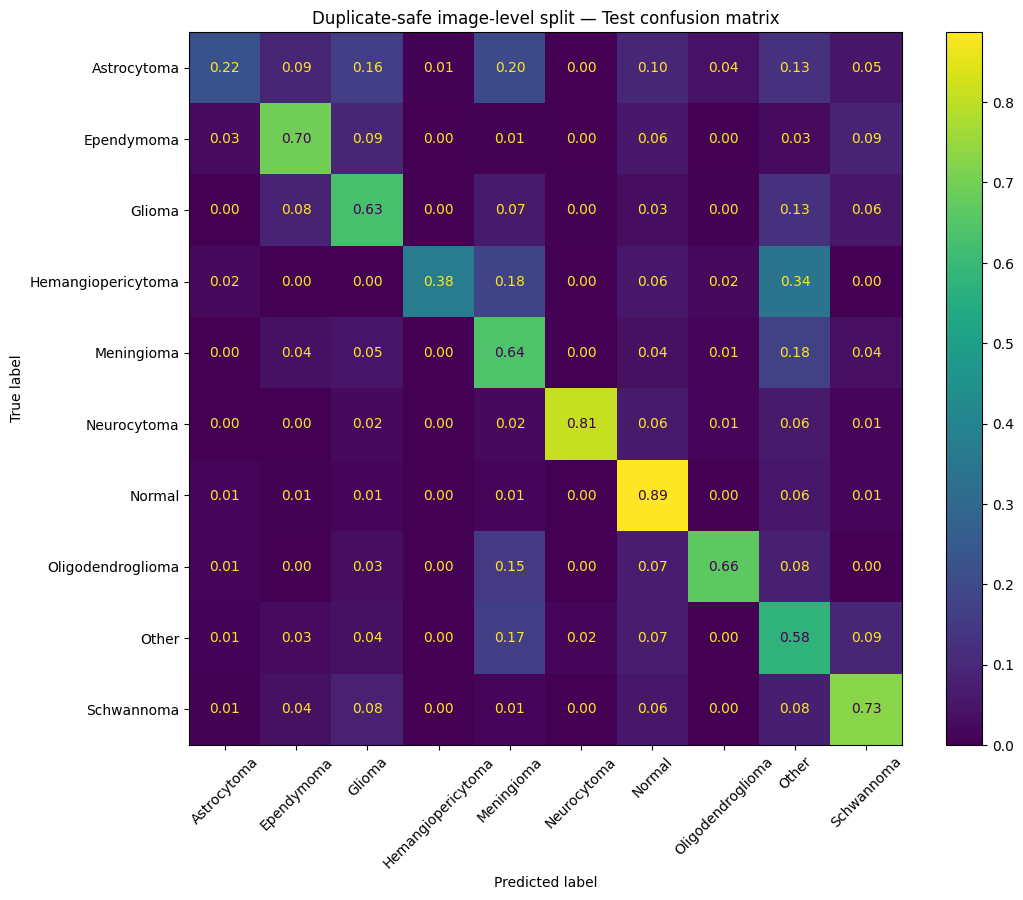

In [26]:
# ============================================================
# Step 6.1 — Normalized confusion matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=CLASS_NAMES,
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Duplicate-safe image-level split — Test confusion matrix"
)

plt.tight_layout()
plt.show()

### Diagnostic split experiment — conclusion

To investigate whether the poor performance observed under the reconstructed group-disjoint protocol was primarily caused by model limitations or by the evaluation protocol itself, an additional diagnostic experiment was conducted.

A duplicate-safe image-level split was constructed using exact pixel hashes as indivisible units. This ensured that pixel-identical images could never appear across training, validation, and test sets, while allowing different images belonging to the same reconstructed `split_group` to occur in multiple partitions.

The resulting split contained 7,965 training images, 1,659 validation images, and 1,676 test images. No exact pixel hash crossed partitions. However, 334 of the 357 reconstructed groups (93.56%) occurred in more than one partition, providing a deliberately less conservative evaluation setting than the original group-disjoint protocol.

Using the same EfficientNetV2B0 architecture, the frozen-backbone stage reached 61.0% validation accuracy. Partial fine-tuning of the final backbone layers further improved validation performance to approximately 65%.

On the held-out test set, the final model achieved:

- **Accuracy:** 62.35%
- **Macro F1-score:** 0.630
- **Weighted F1-score:** 0.614
- **Test loss:** 1.068

Performance remained heterogeneous across pathologies. Recall was particularly high for Normal (88.7%), Neurocytoma (80.9%), and Schwannoma (72.8%), while Astrocytoma (22.3%) and Hemangiopericytoma (37.5%) remained substantially more difficult.

These results contrast strongly with the approximately 30% performance obtained under the reconstructed group-disjoint evaluation protocol. Because exact duplicate leakage was explicitly prevented in the diagnostic split, the improvement cannot be attributed to pixel-identical images occurring across partitions.

Instead, the experiment demonstrates that model performance is highly sensitive to the assumed unit of independence used during dataset splitting. Generalization to entirely unseen reconstructed groups is substantially harder than classification when different images from the same reconstructed groups are represented across partitions.

Importantly, this experiment does **not** establish that the reconstructed `split_group` identifiers correspond to true patient identities, nor does it establish that the image-level protocol provides a clinically valid estimate of generalization. The dataset does not provide verified patient identifiers, preventing definitive patient-level evaluation.

Therefore, the two protocols should be interpreted as complementary bounds rather than competing estimates of a single "true" model performance. The diagnostic split demonstrates that the classification task is learnable by the model, whereas the group-disjoint experiment reveals poor robustness to unseen reconstructed cases/groups.

This sensitivity to split methodology is itself a central finding of the dataset audit and highlights the importance of explicit patient-level provenance when evaluating medical imaging models.

## 7. Model interpretability and lesion localization

The classification experiments revealed substantial sensitivity to the
dataset splitting strategy. We now investigate whether the model's
predictions are supported by image regions that are spatially consistent
with the lesion annotations provided by the dataset.

Grad-CAM is used to visualize the regions contributing to each prediction,
and the resulting attention maps are compared with the provided lesion
center coordinates (`point`).

In [27]:
# ============================================================
# Step 7.1 — Inspect EfficientNet backbone
# ============================================================

backbone_model = best_model.get_layer("efficientnetv2-b0")

print("Backbone:", backbone_model.name)
print("Number of layers:", len(backbone_model.layers))

print("\nLast 15 backbone layers:")
for layer in backbone_model.layers[-15:]:
    print(
        f"{layer.name:35s}",
        "→",
        layer.output.shape
    )

Backbone: efficientnetv2-b0
Number of layers: 270

Last 15 backbone layers:
block6h_dwconv2                     → (None, 7, 7, 1152)
block6h_bn                          → (None, 7, 7, 1152)
block6h_activation                  → (None, 7, 7, 1152)
block6h_se_squeeze                  → (None, 1152)
block6h_se_reshape                  → (None, 1, 1, 1152)
block6h_se_reduce                   → (None, 1, 1, 48)
block6h_se_expand                   → (None, 1, 1, 1152)
block6h_se_excite                   → (None, 7, 7, 1152)
block6h_project_conv                → (None, 7, 7, 192)
block6h_project_bn                  → (None, 7, 7, 192)
block6h_drop                        → (None, 7, 7, 192)
block6h_add                         → (None, 7, 7, 192)
top_conv                            → (None, 7, 7, 1280)
top_bn                              → (None, 7, 7, 1280)
top_activation                      → (None, 7, 7, 1280)


In [28]:
# ============================================================
# Step 7.2 — Select one correctly classified tumor example
# ============================================================

test_analysis = test_df.copy()

test_analysis["y_true"] = y_true
test_analysis["y_pred"] = y_pred

test_analysis["predicted_pathology"] = [
    CLASS_NAMES[i] for i in y_pred
]

test_analysis["correct"] = (
    test_analysis["y_true"] == test_analysis["y_pred"]
)

correct_tumor_examples = test_analysis[
    (test_analysis["correct"]) &
    (test_analysis["pathology"] != "Normal")
]

example = correct_tumor_examples.iloc[0]

print("True pathology      :", example["pathology"])
print("Predicted pathology :", example["predicted_pathology"])
print("Modality            :", example["modality"])
print("Point               :", example["point"])
print("Image               :", example["current_path"])

True pathology      : Astrocytoma
Predicted pathology : Astrocytoma
Modality            : T1C+
Point               : {'x': 332, 'y': 221}
Image               : /content/brain-tumor-mri/data/raw/Astrocytoma T1C+/T1C+ - Diffuse astrocytoma NOS (protoplasmic) frontal 039.jpg


In [29]:
# ============================================================
# Step 7.3 — Grad-CAM function
# ============================================================

LAST_CONV_LAYER = "top_conv"

# Model returning both top_conv features and final backbone output
feature_extractor = keras.Model(
    inputs=backbone_model.input,
    outputs=[
        backbone_model.get_layer(LAST_CONV_LAYER).output,
        backbone_model.output
    ]
)

# Layers after the backbone in our classifier
gap_layer = best_model.get_layer("global_average_pooling2d")
dropout_layer = best_model.get_layer("dropout")
classifier_layer = best_model.get_layer("dense")


def make_gradcam_heatmap(img_batch, class_index=None):

    with tf.GradientTape() as tape:

        # Apply augmentation layer in inference mode:
        # no random transformation will be performed
        x = best_model.get_layer("data_augmentation")(
            img_batch,
            training=False
        )

        conv_output, backbone_output = feature_extractor(
            x,
            training=False
        )

        x = gap_layer(backbone_output)
        x = dropout_layer(x, training=False)
        predictions = classifier_layer(x)

        if class_index is None:
            class_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[:, class_index]

    # Gradient of class score with respect to feature maps
    grads = tape.gradient(
        class_score,
        conv_output
    )

    # Importance of each feature channel
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_output[0] * pooled_grads,
        axis=-1
    )

    # ReLU: retain positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize to [0, 1]
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy(), predictions.numpy()

In [30]:
# ============================================================
# Step 7.4 — Generate first Grad-CAM
# ============================================================

image_bytes = tf.io.read_file(
    example["current_path"]
)

image = tf.io.decode_jpeg(
    image_bytes,
    channels=3
)

original_image = image.numpy()

image_resized = tf.image.resize(
    image,
    IMG_SIZE
)

img_batch = tf.expand_dims(
    image_resized,
    axis=0
)

heatmap, prediction = make_gradcam_heatmap(
    img_batch
)

pred_idx = int(np.argmax(prediction[0]))

print("Heatmap shape :", heatmap.shape)
print("Heatmap min   :", heatmap.min())
print("Heatmap max   :", heatmap.max())

print(
    "Prediction    :",
    CLASS_NAMES[pred_idx]
)

print(
    "Confidence    :",
    float(prediction[0][pred_idx])
)

Heatmap shape : (7, 7)
Heatmap min   : 0.0
Heatmap max   : 1.0
Prediction    : Astrocytoma
Confidence    : 0.3996756076812744


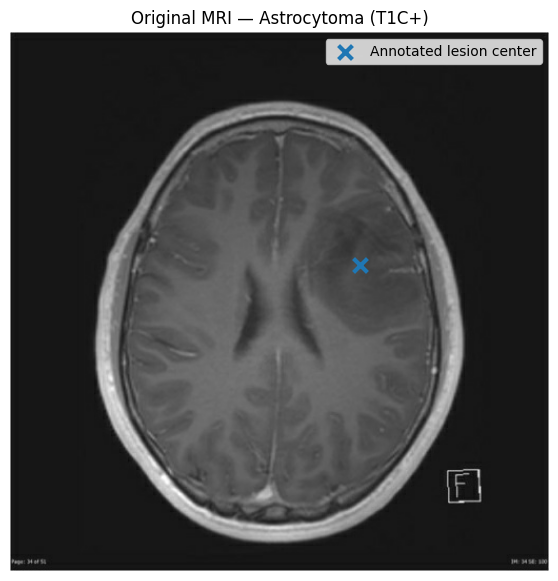

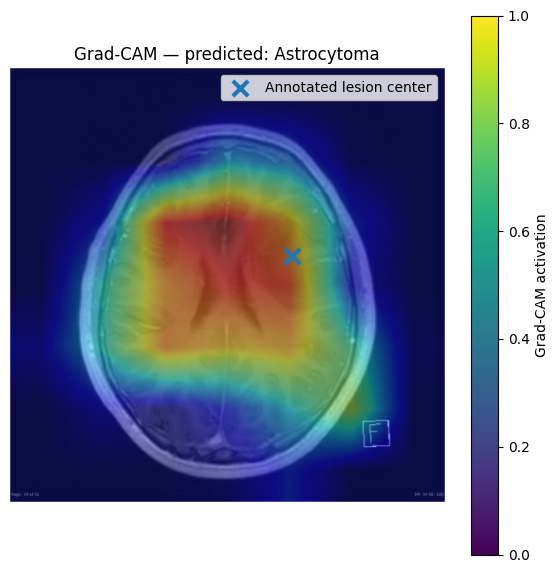

In [31]:
# ============================================================
# Step 7.5 — Visualize Grad-CAM with lesion center
# ============================================================

import ast
import matplotlib.pyplot as plt

# Parse point if stored as a string
point = example["point"]

if isinstance(point, str):
    point = ast.literal_eval(point)

point_x = point["x"]
point_y = point["y"]

# Original dimensions
original_h, original_w = original_image.shape[:2]

# Resize Grad-CAM from 7x7 to original image size
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (original_h, original_w)
).numpy().squeeze()


# ------------------------------------------------------------
# Original MRI
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.imshow(original_image, cmap="gray")

plt.scatter(
    point_x,
    point_y,
    s=100,
    marker="x",
    linewidths=3,
    label="Annotated lesion center"
)

plt.title(
    f"Original MRI — {example['pathology']} ({example['modality']})"
)

plt.legend()
plt.axis("off")
plt.show()


# ------------------------------------------------------------
# Grad-CAM overlay
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.imshow(original_image, cmap="gray")

plt.imshow(
    heatmap_resized,
    alpha=0.45,
    cmap="jet"
)

plt.scatter(
    point_x,
    point_y,
    s=120,
    marker="x",
    linewidths=3,
    label="Annotated lesion center"
)

plt.title(
    f"Grad-CAM — predicted: {example['predicted_pathology']}"
)

plt.colorbar(
    label="Grad-CAM activation"
)

plt.legend()
plt.axis("off")
plt.show()

In [32]:
# ============================================================
# Step 7.6 — Quantify Grad-CAM attention around lesion point
# ============================================================

def lesion_attention_metrics(
    heatmap_resized,
    point_x,
    point_y,
    radius=30
):
    h, w = heatmap_resized.shape

    x = int(round(point_x))
    y = int(round(point_y))

    # Activation exactly at annotated lesion center
    point_activation = float(
        heatmap_resized[y, x]
    )

    # Circular neighborhood around lesion center
    yy, xx = np.ogrid[:h, :w]

    lesion_mask = (
        (xx - x) ** 2 +
        (yy - y) ** 2
        <= radius ** 2
    )

    local_activation = float(
        heatmap_resized[lesion_mask].mean()
    )

    # Where does the lesion-center activation rank
    # compared with the complete image?
    percentile = float(
        100 *
        np.mean(
            heatmap_resized <= point_activation
        )
    )

    return {
        "point_activation": point_activation,
        "local_activation_r30": local_activation,
        "point_percentile": percentile
    }


metrics = lesion_attention_metrics(
    heatmap_resized,
    point_x,
    point_y,
    radius=30
)

for key, value in metrics.items():
    print(f"{key:25s}: {value:.4f}")

point_activation         : 0.7674
local_activation_r30     : 0.7343
point_percentile         : 92.0967


In [33]:
# ============================================================
# Step 7.7 — Grad-CAM metrics across tumor test images
# ============================================================

import ast
from tqdm.auto import tqdm

tumor_test = test_analysis[
    test_analysis["pathology"] != "Normal"
].copy()

gradcam_results = []


for idx, row in tqdm(
    tumor_test.iterrows(),
    total=len(tumor_test)
):

    # ----------------------------------------
    # Load image
    # ----------------------------------------

    image_bytes = tf.io.read_file(
        row["current_path"]
    )

    image = tf.io.decode_jpeg(
        image_bytes,
        channels=3
    )

    original_h = int(image.shape[0])
    original_w = int(image.shape[1])

    image_resized = tf.image.resize(
        image,
        IMG_SIZE
    )

    img_batch = tf.expand_dims(
        image_resized,
        axis=0
    )

    # ----------------------------------------
    # Grad-CAM for predicted class
    # ----------------------------------------

    heatmap, prediction = make_gradcam_heatmap(
        img_batch
    )

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (original_h, original_w)
    ).numpy().squeeze()

    # ----------------------------------------
    # Parse lesion point
    # ----------------------------------------

    point = row["point"]

    if isinstance(point, str):
        point = ast.literal_eval(point)

    point_x = point["x"]
    point_y = point["y"]

    # ----------------------------------------
    # Lesion attention
    # ----------------------------------------

    metrics = lesion_attention_metrics(
        heatmap_resized,
        point_x,
        point_y,
        radius=30
    )

    gradcam_results.append({
        "index": idx,
        "pathology": row["pathology"],
        "modality": row["modality"],
        "correct": row["correct"],
        "predicted_pathology": row["predicted_pathology"],
        **metrics
    })


gradcam_df = pd.DataFrame(
    gradcam_results
)

print("Tumor images analyzed:", len(gradcam_df))

display(
    gradcam_df[
        [
            "point_activation",
            "local_activation_r30",
            "point_percentile"
        ]
    ].describe()
)

  0%|          | 0/1516 [00:00<?, ?it/s]

Tumor images analyzed: 1516


,point_activation,local_activation_r30,point_percentile
count,1516.000000,1516.000000,1516.000000
mean,0.324303,0.322211,64.205376
std,0.289119,0.276726,28.575601
min,0.000000,0.000000,1.631927
25%,0.027630,0.050398,40.116119
50%,0.267598,0.271061,72.089767
75%,0.566502,0.549037,90.044498
max,0.984464,0.965731,99.963379


In [34]:
# ============================================================
# Step 7.8 — Lesion attention: correct vs incorrect predictions
# ============================================================

comparison = (
    gradcam_df
    .groupby("correct")
    .agg(
        n=("point_percentile", "size"),
        mean_point_activation=("point_activation", "mean"),
        median_point_activation=("point_activation", "median"),
        mean_local_activation=("local_activation_r30", "mean"),
        median_local_activation=("local_activation_r30", "median"),
        mean_point_percentile=("point_percentile", "mean"),
        median_point_percentile=("point_percentile", "median")
    )
)

display(comparison.round(3))

,n,mean_point_activation,median_point_activation,mean_local_activation,median_local_activation,mean_point_percentile,median_point_percentile
correct,,,,,,,
False,613,0.263,0.173,0.262,0.183,58.628,62.179
True,903,0.366,0.344,0.363,0.345,67.992,78.292


In [35]:
from scipy.stats import mannwhitneyu

correct_percentiles = gradcam_df.loc[
    gradcam_df["correct"],
    "point_percentile"
]

incorrect_percentiles = gradcam_df.loc[
    ~gradcam_df["correct"],
    "point_percentile"
]

stat, p_value = mannwhitneyu(
    correct_percentiles,
    incorrect_percentiles,
    alternative="two-sided"
)

print(
    "Median percentile — correct   :",
    round(correct_percentiles.median(), 2)
)

print(
    "Median percentile — incorrect :",
    round(incorrect_percentiles.median(), 2)
)

print(f"Mann–Whitney U p-value         : {p_value:.6g}")

Median percentile — correct   : 78.29
Median percentile — incorrect : 62.18
Mann–Whitney U p-value         : 2.5164e-11


In [36]:
# ============================================================
# Step 7.9 — Lesion vs mirrored anatomical control
# ============================================================

control_results = []

for idx, row in tqdm(
    tumor_test.iterrows(),
    total=len(tumor_test)
):

    # Load image
    image_bytes = tf.io.read_file(row["current_path"])
    image = tf.io.decode_jpeg(image_bytes, channels=3)

    h = int(image.shape[0])
    w = int(image.shape[1])

    image_resized = tf.image.resize(image, IMG_SIZE)
    img_batch = tf.expand_dims(image_resized, axis=0)

    # Grad-CAM
    heatmap, _ = make_gradcam_heatmap(img_batch)

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (h, w)
    ).numpy().squeeze()

    # Lesion point
    point = row["point"]

    if isinstance(point, str):
        point = ast.literal_eval(point)

    x = point["x"]
    y = point["y"]

    # Mirrored control point around image center
    control_x = (w - 1) - x
    control_y = (h - 1) - y

    lesion_metrics = lesion_attention_metrics(
        heatmap_resized,
        x,
        y,
        radius=30
    )

    control_metrics = lesion_attention_metrics(
        heatmap_resized,
        control_x,
        control_y,
        radius=30
    )

    control_results.append({
        "index": idx,
        "pathology": row["pathology"],
        "modality": row["modality"],
        "correct": row["correct"],

        "lesion_local_activation":
            lesion_metrics["local_activation_r30"],

        "control_local_activation":
            control_metrics["local_activation_r30"],

        "lesion_percentile":
            lesion_metrics["point_percentile"],

        "control_percentile":
            control_metrics["point_percentile"]
    })


control_df = pd.DataFrame(control_results)

control_df["activation_difference"] = (
    control_df["lesion_local_activation"]
    - control_df["control_local_activation"]
)

control_df["percentile_difference"] = (
    control_df["lesion_percentile"]
    - control_df["control_percentile"]
)

print("Images analyzed:", len(control_df))

display(
    control_df[
        [
            "lesion_local_activation",
            "control_local_activation",
            "activation_difference",
            "lesion_percentile",
            "control_percentile",
            "percentile_difference"
        ]
    ].describe().round(3)
)

  0%|          | 0/1516 [00:00<?, ?it/s]

Images analyzed: 1516


,lesion_local_activation,control_local_activation,activation_difference,lesion_percentile,control_percentile,percentile_difference
count,1516.000,1516.000,1516.000,1516.000,1516.000,1516.000
mean,0.322,0.307,0.015,64.205,61.617,2.588
std,0.277,0.285,0.308,28.576,29.463,29.410
min,0.000,0.000,-0.871,1.632,1.366,-91.380
25%,0.050,0.034,-0.156,40.116,35.050,-11.051
50%,0.271,0.242,0.000,72.090,67.168,0.000
75%,0.549,0.527,0.174,90.044,89.617,15.568
max,0.966,0.961,0.850,99.963,99.982,97.493


In [37]:
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(
    control_df["lesion_local_activation"],
    control_df["control_local_activation"],
    alternative="greater"
)

print(
    "Median lesion activation :",
    round(
        control_df["lesion_local_activation"].median(),
        3
    )
)

print(
    "Median control activation:",
    round(
        control_df["control_local_activation"].median(),
        3
    )
)

print(
    "Median difference        :",
    round(
        control_df["activation_difference"].median(),
        3
    )
)

print(
    "% lesion > control      :",
    round(
        100 * (
            control_df["activation_difference"] > 0
        ).mean(),
        2
    ),
    "%"
)

print(
    f"Wilcoxon one-sided p-value: {p_value:.6g}"
)

Median lesion activation : 0.271
Median control activation: 0.242
Median difference        : 0.0
% lesion > control      : 48.88 %
Wilcoxon one-sided p-value: 0.0651588


In [38]:
# ============================================================
# Step 7.10 — Lesion preference by pathology and modality
# ============================================================

pathology_attention = (
    control_df
    .groupby("pathology")
    .agg(
        n=("activation_difference", "size"),
        median_lesion_activation=("lesion_local_activation", "median"),
        median_control_activation=("control_local_activation", "median"),
        median_difference=("activation_difference", "median"),
        mean_difference=("activation_difference", "mean"),
        lesion_preferred_pct=(
            "activation_difference",
            lambda x: 100 * (x > 0).mean()
        )
    )
    .sort_values(
        "median_difference",
        ascending=False
    )
)

print("By pathology:")
display(pathology_attention.round(3))


modality_attention = (
    control_df
    .groupby("modality")
    .agg(
        n=("activation_difference", "size"),
        median_lesion_activation=("lesion_local_activation", "median"),
        median_control_activation=("control_local_activation", "median"),
        median_difference=("activation_difference", "median"),
        mean_difference=("activation_difference", "mean"),
        lesion_preferred_pct=(
            "activation_difference",
            lambda x: 100 * (x > 0).mean()
        )
    )
    .sort_values(
        "median_difference",
        ascending=False
    )
)

print("\nBy modality:")
display(modality_attention.round(3))

By pathology:


,n,median_lesion_activation,median_control_activation,median_difference,mean_difference,lesion_preferred_pct
pathology,,,,,,
Meningioma,308,0.313,0.169,0.073,0.104,60.714
Neurocytoma,94,0.276,0.230,0.026,0.027,63.830
Schwannoma,173,0.225,0.059,0.006,0.041,54.913
Oligodendroglioma,89,0.387,0.335,0.002,0.033,51.685
Hemangiopericytoma,88,0.209,0.257,0.000,-0.008,48.864
Other,235,0.209,0.168,0.000,0.044,48.085
Astrocytoma,166,0.261,0.318,-0.000,-0.021,45.181
Glioma,215,0.186,0.348,-0.059,-0.094,30.698
Ependymoma,148,0.501,0.538,-0.077,-0.054,37.838



By modality:


,n,median_lesion_activation,median_control_activation,median_difference,mean_difference,lesion_preferred_pct
modality,,,,,,
T1,487,0.271,0.210,0.001,0.043,50.719
T1C+,650,0.259,0.237,0.000,0.021,50.923
T2,379,0.302,0.312,-0.005,-0.030,43.008


### Grad-CAM lesion-attention analysis

Grad-CAM was used to investigate whether the classifier's decisions were
spatially associated with the lesion-center annotations provided by the
dataset.

A first qualitative example showed that the annotated tumor center could
fall within a highly activated region. However, because the final
convolutional feature map has a spatial resolution of only 7 × 7, Grad-CAM
localization was relatively coarse and frequently covered large anatomical
regions. Therefore, qualitative heatmaps alone were not considered
sufficient evidence of lesion-specific attention.

Grad-CAM was subsequently evaluated quantitatively on all 1,516 tumor
images in the duplicate-safe test set. Across these images, the median
percentile of Grad-CAM activation at the annotated lesion center was 72.1,
although the distribution was highly heterogeneous.

Lesion-centered attention was substantially stronger for correctly
classified images. The median lesion-center activation percentile was
78.29 for correct predictions compared with 62.18 for incorrect
predictions. This difference was statistically significant using a
two-sided Mann–Whitney U test (p = 2.52 × 10⁻¹¹). Thus, stronger attention
around the annotated lesion was associated with successful classification.

To determine whether this represented lesion-specific attention rather
than broad anatomical activation, each lesion location was additionally
compared with a mirrored control location at the same distance from the
image center. Across the 1,516 tumor images, median local Grad-CAM
activation was 0.271 around the lesion and 0.242 around the mirrored
control. The median paired difference was 0.000, and lesion activation
exceeded control activation in only 48.88% of images. A one-sided paired
Wilcoxon test did not provide statistically significant evidence of
systematically greater lesion-centered activation (p = 0.065).

Descriptive subgroup analysis further showed substantial heterogeneity
across pathologies. Meningioma showed the clearest lesion preference
(median lesion-control difference = +0.073; lesion preferred in 60.7% of
images), whereas Glioma showed the opposite pattern (median difference =
−0.059; lesion preferred in 30.7%). In contrast, modality did not reveal a
clear lesion-attention advantage: lesion preference occurred in 50.7% of
T1, 50.9% of T1C+, and 43.0% of T2 images.

Overall, stronger lesion-centered Grad-CAM attention was associated with
correct classification, but the model did not systematically prioritize
the annotated lesion over a comparable anatomical control location.
Consequently, the Grad-CAM results should not be interpreted as evidence
that the classifier reliably localizes tumors or bases its decisions
primarily on tumor tissue. Instead, they suggest that the model relies on
broader and pathology-dependent spatial patterns, with lesion-focused
attention contributing to successful predictions in some cases.

In [39]:
# ============================================================
# Step 8 — Test performance by MRI modality
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

modality_results = []

for modality, group in test_analysis.groupby("modality"):

    y_true_mod = group["y_true"].to_numpy()
    y_pred_mod = group["y_pred"].to_numpy()

    modality_results.append({
        "modality": modality,
        "n_images": len(group),

        "accuracy": accuracy_score(
            y_true_mod,
            y_pred_mod
        ),

        "macro_f1": f1_score(
            y_true_mod,
            y_pred_mod,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_true_mod,
            y_pred_mod,
            average="weighted",
            zero_division=0
        )
    })


modality_performance = (
    pd.DataFrame(modality_results)
    .set_index("modality")
    .sort_index()
)

display(
    modality_performance.round(3)
)

,n_images,accuracy,macro_f1,weighted_f1
modality,,,,
T1,554,0.630,0.627,0.621
T1C+,688,0.674,0.696,0.670
T2,434,0.535,0.486,0.500


In [40]:
# ============================================================
# Step 8.1 — Recall by pathology × modality
# ============================================================

pathology_modality = (
    test_analysis
    .groupby(
        ["pathology", "modality"]
    )
    .agg(
        n_images=("correct", "size"),
        recall=("correct", "mean")
    )
    .reset_index()
)

recall_matrix = (
    pathology_modality
    .pivot(
        index="pathology",
        columns="modality",
        values="recall"
    )
)

count_matrix = (
    pathology_modality
    .pivot(
        index="pathology",
        columns="modality",
        values="n_images"
    )
)

print("Recall:")
display(
    recall_matrix.round(3)
)

print("\nNumber of test images:")
display(
    count_matrix
)

Recall:


modality,T1,T1C+,T2
pathology,,,
Astrocytoma,0.317,0.250,0.047
Ependymoma,0.766,0.722,0.596
Glioma,0.656,0.681,0.524
Hemangiopericytoma,0.308,0.556,0.000
Meningioma,0.624,0.689,0.554
Neurocytoma,0.583,0.966,0.931
Normal,0.866,0.842,0.945
Oligodendroglioma,0.737,0.704,0.500
Other,0.542,0.687,0.375



Number of test images:


modality,T1,T1C+,T2
pathology,,,
Astrocytoma,63,60,43
Ependymoma,47,54,47
Glioma,61,91,63
Hemangiopericytoma,26,45,17
Meningioma,101,151,56
Neurocytoma,36,29,29
Normal,67,38,55
Oligodendroglioma,38,27,24
Other,72,115,48


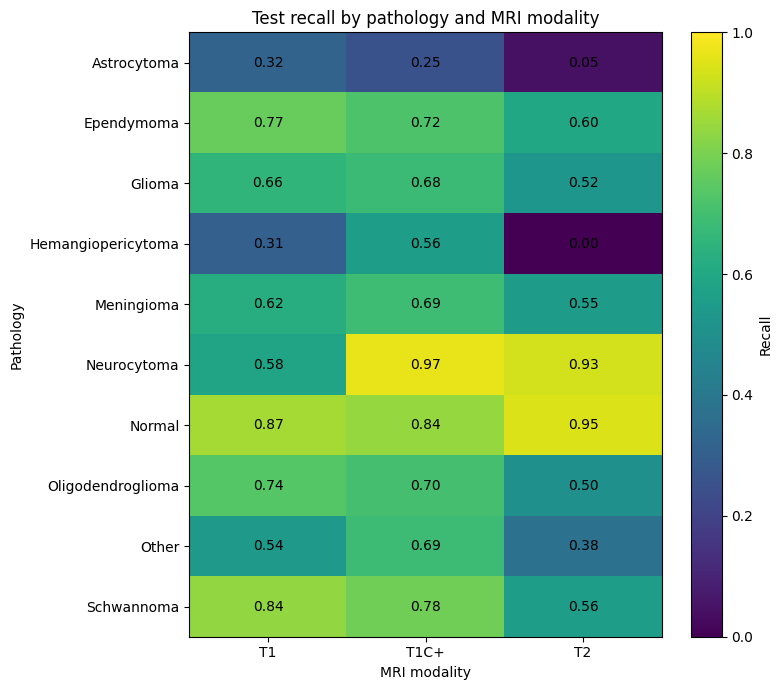

In [41]:
# ============================================================
# Step 8.2 — Pathology × modality recall heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    recall_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(recall_matrix.columns))
)

ax.set_xticklabels(
    recall_matrix.columns
)

ax.set_yticks(
    range(len(recall_matrix.index))
)

ax.set_yticklabels(
    recall_matrix.index
)

for i in range(len(recall_matrix.index)):
    for j in range(len(recall_matrix.columns)):

        value = recall_matrix.iloc[i, j]

        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

ax.set_xlabel("MRI modality")
ax.set_ylabel("Pathology")
ax.set_title(
    "Test recall by pathology and MRI modality"
)

fig.colorbar(
    im,
    ax=ax,
    label="Recall"
)

plt.tight_layout()
plt.show()

### Performance across MRI modalities

Model performance was not uniform across MRI modalities.

T1C+ produced the strongest overall results, reaching 67.4% accuracy and
a macro F1-score of 0.696. T1 showed intermediate performance (63.0%
accuracy; macro F1 = 0.627), whereas T2 performance was substantially
lower (53.5% accuracy; macro F1 = 0.486).

However, the modality effect was strongly pathology-dependent. T2 was
particularly challenging for Astrocytoma (4.7% recall) and
Hemangiopericytoma (0.0%), and also showed reduced recall for several
other tumor classes. In contrast, T2 achieved very high recall for Normal
(94.5%) and Neurocytoma (93.1%).

T1C+ provided the most consistently strong performance across tumor
categories, although no modality resolved all classification difficulties.
Astrocytoma remained difficult across T1 (31.7%), T1C+ (25.0%), and
especially T2 (4.7%).

These results indicate that classification performance depends not only
on pathology but also on the interaction between pathology and MRI
modality. Consequently, aggregate performance metrics can conceal
substantial modality-specific failure modes.

This observation is particularly relevant because modality was deliberately
excluded from the prediction target and retained as metadata. The results
therefore suggest that MRI sequence characteristics remain an important
source of performance heterogeneity even when the intended task is
pathology classification.

## 9. Final V1 synthesis

### Experimental summary

| Analysis | Main result |
|---|---|
| Dataset size | 11,300 MRI images |
| Target | 10 pathology classes |
| MRI modalities | T1, T1C+, T2 |
| Reconstructed groups | 357 `split_group` units |
| Exact unique images | 9,435 pixel hashes |
| Group-disjoint evaluation | ~30% test accuracy |
| Duplicate-safe image-level evaluation | 62.35% test accuracy |
| Duplicate-safe macro F1 | 0.630 |
| Duplicate-safe weighted F1 | 0.614 |
| Best modality | T1C+ — 67.4% accuracy, 0.696 macro F1 |
| T1 performance | 63.0% accuracy, 0.627 macro F1 |
| T2 performance | 53.5% accuracy, 0.486 macro F1 |
| Grad-CAM lesion attention | Higher for correct than incorrect predictions |
| Lesion vs mirrored control | No significant systematic lesion preference (p = 0.065) |

### Key findings

This study began as a 10-class brain MRI classification task but revealed
that evaluation methodology was at least as important as model
architecture.

The dataset contains substantial internal dependence. Among 11,300 images,
only 9,435 unique pixel hashes were identified, and metadata and naming
patterns suggested the existence of repeated images and groups of related
MRI acquisitions. Because verified patient identifiers were unavailable,
357 reconstructed `split_group` units were used as conservative proxies
for related cases during the primary evaluation.

Under a group-disjoint protocol, EfficientNetV2B0 generalized poorly to
entirely unseen reconstructed groups, with performance remaining around
30% despite weighting, sampling, and partial fine-tuning experiments.

A diagnostic duplicate-safe image-level protocol produced a markedly
different result. Exact pixel duplicates were kept within a single
partition, while different images from the same reconstructed groups were
allowed across partitions. Under this setting, EfficientNetV2B0 achieved
62.35% test accuracy and a macro F1-score of 0.630.

This large performance gap demonstrates that evaluation results are highly
sensitive to the assumed unit of statistical independence. The diagnostic
experiment confirms that the image classification task is learnable, but
it does not establish patient-level generalization. Conversely, the
group-disjoint experiment provides a substantially more conservative
stress test, but the reconstructed groups cannot be assumed to represent
verified patient identities.

Performance was also heterogeneous across both pathologies and MRI
modalities. T1C+ achieved the strongest aggregate performance (67.4%
accuracy), followed by T1 (63.0%), while T2 was substantially more
challenging (53.5%). These differences were pathology-dependent rather
than uniform across classes.

Explainability analysis further showed that stronger Grad-CAM activation
around the annotated lesion center was associated with correct
classification. However, lesion-centered activation was not significantly
greater than activation around a mirrored anatomical control location
across the full tumor test set. Therefore, the classifier cannot be
assumed to systematically base its decisions on tumor tissue alone.

Together, these findings show that classification accuracy by itself would
provide an incomplete and potentially misleading characterization of model
performance on this dataset.

### Limitations and interpretation

The principal limitation of this study is the absence of verified patient
identifiers. Although reconstructed groups are supported by filename
structure, metadata consistency, modality relationships, descriptions,
and exact duplicate analysis, they cannot be interpreted as confirmed
patient identities.

Consequently, neither evaluation protocol should be considered a definitive
estimate of clinical generalization.

The duplicate-safe image-level protocol should be interpreted primarily as
a diagnostic experiment demonstrating task learnability under reduced
case-level distribution shift. Its 62.35% test accuracy must not be
presented as patient-independent or clinically validated performance.

The group-disjoint protocol provides a more conservative estimate of
generalization to unseen reconstructed cases, but may impose stronger
separation than true patient-level grouping if some reconstructed groups
combine acquisitions that do not belong to the same patient.

Grad-CAM also provides only coarse post-hoc explanations. The final
convolutional feature maps have a spatial resolution of 7 × 7, preventing
precise lesion localization. The provided lesion annotations represent
center points rather than segmentation masks, further limiting spatial
validation.


### V1 conclusion

The main outcome of this project is not a single classification accuracy,
but the demonstration that brain MRI classification performance can change
substantially depending on how independence between samples is defined.

A conventional image-level evaluation, even after removing exact duplicate
leakage, produced substantially stronger performance than evaluation on
entirely unseen reconstructed groups. At the same time, explainability and
modality-specific analyses revealed additional failure modes that aggregate
metrics alone would have concealed.

These findings reinforce three methodological requirements for medical
imaging machine learning:

1. explicit patient-level provenance,
2. leakage-aware evaluation protocols,
3. validation that predictive performance is supported by clinically
   relevant image regions rather than dataset-specific shortcuts.
